# Machine Learning Lab – Exercise 1

## Chicago Taxi Fare Prediction using Linear Regression

### Objective
To train a Linear Regression model to predict the fare of a taxi ride in Chicago, Illinois, using the City of Chicago Taxi Trips dataset.

### Algorithm Used
Linear Regression

### Problem Type
Supervised Learning – Regression

### Steps
1. Load the required libraries.
2. Load the Chicago Taxi Trips dataset.
3. Explore the dataset.
4. Check for missing values.
5. Select the relevant input features and target variable.
6. Split the data into training and testing sets.
7. Train the Linear Regression model.
8. Predict taxi fares for the test data.
9. Evaluate the model using suitable regression metrics.
10. Visualize the actual and predicted fares.
11. Summarize the results.

## Dataset

### Dataset Name
City of Chicago Taxi Trips

### Dataset Source
City of Chicago Data Portal

### Description
The dataset contains records of taxi trips in Chicago, including information about trip duration, trip distance, and other trip-related attributes.

### Target Variable
Fare

### Input Features
The relevant numerical trip-related features will be selected after inspecting the dataset.

### Data Source
Official City of Chicago Data Portal

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Chicago Taxi Trips dataset

url = "https://data.cityofchicago.org/resource/wrvz-psew.csv?$limit=5000"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (5000, 23)


In [3]:
# Display the first five rows of the dataset

df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,1adedef3b9733f6a1859137ce37d8c685ad36cea,7d2e7cdd59237335e96b9b1a897a5e48cb4df467e6c092...,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121.0,0.45,NaN,NaN,8.0,8.0,...,0.0,6.75,Credit Card,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,b68a7310d2ba573ce09f55fa546408264e0b3dd7,9454a3cb5d7e8ef84ca9bfff9f1a5d235021fef66b41a8...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,755.0,2.37,1.703183e+10,1.703108e+10,28.0,8.0,...,0.0,11.28,Mobile,City Service,41.885281,-87.657233,POINT (-87.6572331997 41.8852813201),41.899156,-87.626211,POINT (-87.6262105324 41.8991556134)
2,daa582d3e7f5f75efde38872dffd9de42d4f5ff4,3c8a3a5b0785d40229dd7adc5fd0d9620defca885601bf...,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1140.0,10.50,NaN,NaN,3.0,34.0,...,0.0,28.00,Unknown,Taxi Affiliation Services,41.965812,-87.655879,POINT (-87.6558787862 41.96581197),41.842076,-87.633973,POINT (-87.6339734222 41.8420761168)
3,e152a52aceb5d600a63311bbfe9b23ccdb9592dd,b56b31883524426035c290bfdbe4e038baccc814842c10...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,894.0,6.81,NaN,NaN,8.0,3.0,...,0.0,19.32,Mobile,Sun Taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
4,f74fa03a6cf8cdcf668d0726efa1671d398b4450,2fea69c8a6e08471bc4339a05e9ee7955bef68d791f77a...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1473.0,9.94,NaN,NaN,56.0,NaN,...,18.0,44.75,Cash,Sun Taxi,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),NaN,NaN,NaN


In [4]:
# Display all column names

print("Column names in the dataset:")
for column in df.columns:
    print(column)

Column names in the dataset:
trip_id
taxi_id
trip_start_timestamp
trip_end_timestamp
trip_seconds
trip_miles
pickup_census_tract
dropoff_census_tract
pickup_community_area
dropoff_community_area
fare
tips
tolls
extras
trip_total
payment_type
company
pickup_centroid_latitude
pickup_centroid_longitude
pickup_centroid_location
dropoff_centroid_latitude
dropoff_centroid_longitude
dropoff_centroid_location


In [5]:
# Check data types and missing values

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
trip_id                        object
taxi_id                        object
trip_start_timestamp           object
trip_end_timestamp             object
trip_seconds                  float64
trip_miles                    float64
pickup_census_tract           float64
dropoff_census_tract          float64
pickup_community_area         float64
dropoff_community_area        float64
fare                          float64
tips                          float64
tolls                         float64
extras                        float64
trip_total                    float64
payment_type                   object
company                        object
pickup_centroid_latitude      float64
pickup_centroid_longitude     float64
pickup_centroid_location       object
dropoff_centroid_latitude     float64
dropoff_centroid_longitude    float64
dropoff_centroid_location      object
dtype: object

Missing Values:
trip_id                          0
taxi_id                          0
trip_start_ti

In [6]:
# Select relevant columns and remove missing values

model_data = df[["trip_seconds", "trip_miles", "fare"]].copy()

# Remove rows containing missing values
model_data = model_data.dropna()

# Keep only valid positive trip values and fares
model_data = model_data[
    (model_data["trip_seconds"] > 0) &
    (model_data["trip_miles"] > 0) &
    (model_data["fare"] > 0)
]

print("Cleaned dataset shape:", model_data.shape)
print("\nMissing values after cleaning:")
print(model_data.isnull().sum())

Cleaned dataset shape: (4393, 3)

Missing values after cleaning:
trip_seconds    0
trip_miles      0
fare            0
dtype: int64


In [7]:
# Separate input features and target variable

X = model_data[["trip_seconds", "trip_miles"]]
y = model_data["fare"]

print("Input features (X):")
print(X.head())

print("\nTarget variable (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features (X):
   trip_seconds  trip_miles
0         121.0        0.45
1         755.0        2.37
2        1140.0       10.50
3         894.0        6.81
4        1473.0        9.94

Target variable (y):
0     4.25
1     9.00
2    28.00
3    17.30
4    26.75
Name: fare, dtype: float64

X shape: (4393, 2)
y shape: (4393,)


In [8]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data shape:
X_train: (3514, 2)
y_train: (3514,)

Testing data shape:
X_test: (879, 2)
y_test: (879,)


In [9]:
# Train the Linear Regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [10]:
# Display the Linear Regression equation

print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

print("\nLinear Regression Equation:")
print(
    f"Fare = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × trip_seconds) "
    f"+ ({model.coef_[1]:.4f} × trip_miles)"
)

Intercept: 7.238492980201439

Coefficients:
trip_seconds : 0.0008992733724041412
trip_miles : 2.003632612672192

Linear Regression Equation:
Fare = 7.2385 + (0.0009 × trip_seconds) + (2.0036 × trip_miles)


In [11]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 actual fares:")
print(y_test.head(10).values)

print("\nFirst 10 predicted fares:")
print(y_pred[:10])

Predictions generated successfully!

First 10 actual fares:
[10.75 10.   47.25 15.25  5.   25.   19.58 31.5   9.    5.75]

First 10 predicted fares:
[12.03445332 10.44569617 47.37650122 16.8407908   8.5114952  14.52255485
 22.63201363 31.82954135 10.2503339   9.09938055]


In [12]:
# Evaluate the Linear Regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 3.3443746324540364
Mean Squared Error (MSE): 45.63711279612374
Root Mean Squared Error (RMSE): 6.755524612946336
R² Score: 0.8136870484383905


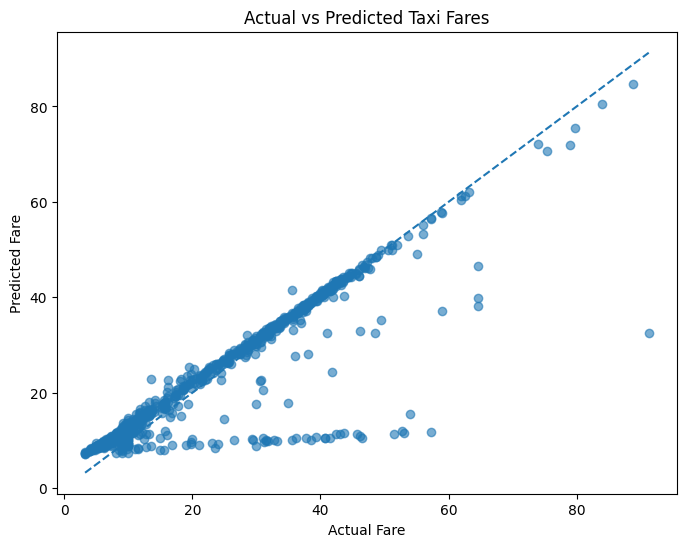

In [13]:
# Visualize actual vs predicted fares

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line: perfect predictions
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Taxi Fares")

plt.show()

In [14]:
# Create a summary of model performance

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

results

,Metric,Value
0,MAE,3.344375
1,MSE,45.637113
2,RMSE,6.755525
3,R² Score,0.813687


## Result

The Linear Regression model was successfully trained using the Chicago Taxi Trips dataset.

The model used `trip_seconds` and `trip_miles` as input features and `fare` as the target variable.

### Model Performance

- Mean Absolute Error (MAE): 3.344375
- Mean Squared Error (MSE): 45.637113
- Root Mean Squared Error (RMSE): 6.755525
- R² Score: 0.813687

The model achieved an R² score of approximately 0.814 on the test dataset.

## Conclusion

The Linear Regression model successfully predicted taxi fares using trip duration and trip distance. The evaluation metrics and the Actual vs Predicted plot show that the model was able to capture a substantial relationship between the selected trip features and taxi fare.
